# Кросс-валидация

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

# Для наглядности – DataFrame
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
iris_data['class'] = [name_map[k] for k in iris['target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


Accuracy: 0.9130434782608695
F1 (macro): 0.9074074074074074


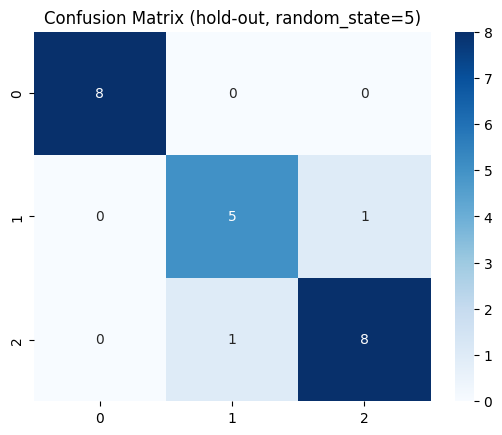

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)

model = LogisticRegression()  # solver по умолчанию (lbfgs) подходит для мультикласса
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))

# Матрица ошибок
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (hold-out, random_state=5)")
plt.show()

Accuracy: 1.0
F1 (macro): 1.0


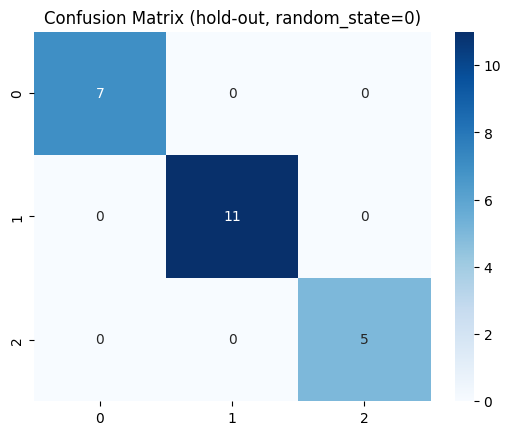

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (hold-out, random_state=0)")
plt.show()

Accuracy: 0.8695652173913043
F1 (macro): 0.8745098039215686


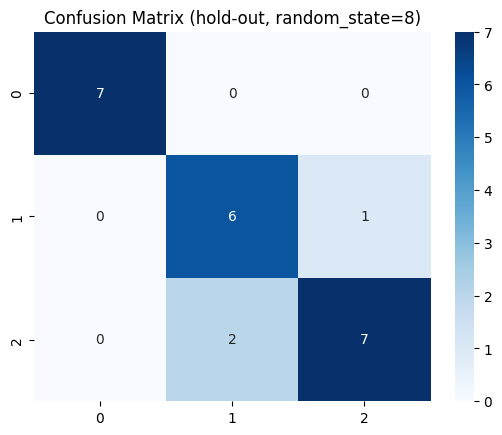

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (hold-out, random_state=8)")
plt.show()

In [19]:
kf = KFold(n_splits=3, shuffle=True, random_state=15)

# Показать размеры блоков
for i, (train_idx, test_idx) in enumerate(kf.split(y)):
    print(f"Fold {i+1}: train size = {len(train_idx)}, test size = {len(test_idx)}")

Fold 1: train size = 100, test size = 50
Fold 2: train size = 100, test size = 50
Fold 3: train size = 100, test size = 50


In [20]:
metrics_accuracy = []
metrics_f1 = []
model = LogisticRegression()   # без liblinear

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics_accuracy.append(accuracy_score(y_test, y_pred))
    metrics_f1.append(f1_score(y_test, y_pred, average='macro'))

print("Accuracy по фолдам:", metrics_accuracy)
print("F1 (macro) по фолдам:", metrics_f1)
print("Средняя Accuracy:", np.mean(metrics_accuracy))
print("Средний F1 (macro):", np.mean(metrics_f1))

Accuracy по фолдам: [1.0, 0.94, 0.94]
F1 (macro) по фолдам: [1.0, 0.9444015444015443, 0.9352142110762801]
Средняя Accuracy: 0.96
Средний F1 (macro): 0.9598719184926082


In [21]:
cv_results_acc = cross_val_score(model, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
cv_results_f1 = cross_val_score(model, X, y, cv=kf, scoring='f1_macro', n_jobs=-1)

print("Accuracy на фолдах:", cv_results_acc)
print("Средняя Accuracy:", cv_results_acc.mean())
print("Стд. отклонение Accuracy:", cv_results_acc.std())

print("\nF1 (macro) на фолдах:", cv_results_f1)
print("Средний F1:", cv_results_f1.mean())
print("Стд. отклонение F1:", cv_results_f1.std())

Accuracy на фолдах: [1.   0.94 0.94]
Средняя Accuracy: 0.96
Стд. отклонение Accuracy: 0.028284271247461926

F1 (macro) на фолдах: [1.         0.94440154 0.93521421]
Средний F1: 0.9598719184926082
Стд. отклонение F1: 0.028621658087367923


In [22]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=15)

# Вывод индексов (можно закомментировать)
for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {i+1}: train size = {len(train_idx)}, test size = {len(test_idx)}")

# Оценка
cv_results_skf = cross_val_score(model, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
print("\nF1 (macro) при стратификации:", cv_results_skf)
print("Средний F1:", cv_results_skf.mean())
print("Стд. отклонение:", cv_results_skf.std())

Fold 1: train size = 100, test size = 50
Fold 2: train size = 100, test size = 50
Fold 3: train size = 100, test size = 50

F1 (macro) при стратификации: [0.95925926 0.95955882 0.96064815]
Средний F1: 0.9598220769789397
Стд. отклонение: 0.0005967857630317648


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
loo = LeaveOneOut()

# Оценка (может выполняться долго – 150 итераций)
cv_results_loo = cross_val_score(model, X, y, cv=loo, scoring='f1_macro', n_jobs=-1)

print("Количество фолдов:", len(cv_results_loo))
print("Средний F1 (macro) по LOO:", cv_results_loo.mean())
print("Стд. отклонение:", cv_results_loo.std())

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    htt

Количество фолдов: 150
Средний F1 (macro) по LOO: 0.9666666666666667
Стд. отклонение: 0.17950549357115014


In [ ]:
loo = LeaveOneOut()

# Оценка
cv_results_loo = cross_val_score(model, X, y, cv=loo, scoring='f1_macro', n_jobs=-1)

print("Количество фолдов:", len(cv_results_loo))
print("Средний F1 (macro) по LOO:", cv_results_loo.mean())
print("Стд. отклонение:", cv_results_loo.std())

Количество фолдов: 150
Средний F1 (macro) по LOO: 0.9666666666666667
Стд. отклонение: 0.17950549357115014


/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    htt

In [ ]:
print("=== Сводка результатов ===")
print(f"Hold-out (random_state=5): Acc = {accuracy_score(y_test, y_pred):.4f}")
print(f"KFold средняя Accuracy: {np.mean(metrics_accuracy):.4f}")
print(f"StratifiedKFold средний F1: {cv_results_skf.mean():.4f}")
print(f"LOO средний F1: {cv_results_loo.mean():.4f}")

=== Сводка результатов ===
Hold-out (random_state=5): Acc = 0.9400 (последний блок)
KFold средняя Accuracy: 0.9600
StratifiedKFold средний F1: 0.9598
LOO средний F1: 0.9667
